# Exploratory Data Analysis of Images for Species Classification
In this notebook I inspect the thermal and rgb images and their respective splits into train, validation, and test dataset.

In [1]:
from species_classification import load_dataset, calc_flight_stats
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

I0000 00:00:1781797339.001058   23235 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [15]:
X_train, y_train, flight_train = load_dataset("../images_filtered/train", "../labels_filtered/train")
X_val, y_val, flight_val = load_dataset("../images_filtered/val", "../labels_filtered/val")
X_test, y_test, flight_test = load_dataset("../images_filtered/test", "../labels_filtered/test")

In [16]:
print("Number of images per split")

print("Train: ", len(X_train))
print("Val: ", len(X_val))
print("Test: ", len(X_test))

Number of images per split
Train:  31037
Val:  5414
Test:  4632


In [7]:
print("Number of images per species per split")

print("Train: ")
for spec, img in zip(np.unique_counts(y_train)[0], np.unique_counts(y_train)[1]):
    print(f"\tclass {spec}: {img} images -> {img/len(y_train):.3f} %")
print("Val: ")
for spec, img in zip(np.unique_counts(y_val)[0], np.unique_counts(y_val)[1]):
    print(f"\tclass {spec}: {img} images -> {img/len(y_val):.3f} %")

print("Test: ")
for spec, img in zip(np.unique_counts(y_test)[0], np.unique_counts(y_test)[1]):
    print(f"\tclass {spec}: {img} images -> {img/len(y_test):.3f} %")
# big problem: only 12 samples of class 2 (Fallow Deer)

Number of images per species per split
Train: 
	class 0: 2751 images -> 0.089 %
	class 1: 10048 images -> 0.324 %
	class 2: 4040 images -> 0.130 %
	class 3: 13496 images -> 0.435 %
	class 4: 702 images -> 0.023 %
Val: 
	class 0: 1732 images -> 0.320 %
	class 1: 2508 images -> 0.463 %
	class 2: 214 images -> 0.040 %
	class 3: 781 images -> 0.144 %
	class 4: 179 images -> 0.033 %
Test: 
	class 0: 961 images -> 0.207 %
	class 1: 1552 images -> 0.335 %
	class 2: 12 images -> 0.003 %
	class 3: 1943 images -> 0.419 %
	class 4: 164 images -> 0.035 %


In [8]:
print("Number of different flights per split")

print("Train: ", len(np.unique(flight_train)))
print("Val: ", len(np.unique(flight_val)))
print("Test: ", len(np.unique(flight_test)))

Number of different flights per split
Train:  159
Val:  24
Test:  42


## Comparing Images of the different datasets

In this section I compared the images from the train, validation, and test dataset with each other. I had a closer look at their brightness, contrast, and range (max pixel value - min pixel value).

In [9]:
calc_flight_stats(flight_train, y_train, X_train)

train flight ids + statistic
for flight 0 and species 3: 
min: 43.16834677419355, max: 83.50828853046595, mean: 58.41942213362821, median: 58.113911290322584
min: 7.254659695211672, max: 23.93287957913204, mean: 16.325999192666103, median: 15.793275320574702
min: 43, max: 249, mean: 165, median: 182
for flight 1 and species 1: 
min: 26.50258064516129, max: 106.43087121212122, mean: 65.68621845326965, median: 65.88442940892861
min: 3.3112926746021074, max: 62.14699557878104, mean: 31.670928417751757, median: 30.265387087841034
min: 34, max: 255, mean: 198, median: 215.0
for flight 2 and species 1: 
min: 23.40462962962963, max: 124.09227594339623, mean: 74.54812128626347, median: 75.56185483870968
min: 4.201958926667975, max: 66.24990695495833, mean: 26.78923239112295, median: 26.48816182410679
min: 28, max: 255, mean: 177, median: 192.0
for flight 3 and species 1: 
min: 27.761708697889862, max: 132.6256868131868, mean: 89.82976834273914, median: 91.72653846153847
min: 3.44473255757519, 

In [10]:
calc_flight_stats(flight_val, y_val, X_val, "val")

val flight ids + statistic
for flight 6 and species 1: 
min: 0.008812260536398468, max: 119.75541299117883, mean: 82.9189712428312, median: 86.27121350940692
min: 0.09941845848731222, max: 81.5263548786059, mean: 42.4435204611765, median: 40.974805433467694
min: 2, max: 255, mean: 226, median: 230.0
for flight 10 and species 1: 
min: 0.0015250544662309367, max: 125.7855464159812, mean: 79.43954415976786, median: 84.20205173951828
min: 0.039022156207800286, max: 62.5800321287395, mean: 26.026398288309522, median: 25.331528301453513
min: 1, max: 255, mean: 181, median: 196
for flight 13 and species 1: 
min: 10.967647058823529, max: 108.20051914341337, mean: 63.20691252082045, median: 65.66939293453567
min: 3.483245399322988, max: 74.3879074040369, mean: 46.726711554307414, median: 46.71306066553147
min: 25, max: 255, mean: 235, median: 243.0
for flight 14 and species 1: 
min: 0.0, max: 141.94509803921568, mean: 75.89041752929585, median: 75.97252747252747
min: 0.0, max: 82.37879521162765

In [11]:
calc_flight_stats(flight_test, y_test, X_test, "test")

test flight ids + statistic
for flight 55 and species 1: 
min: 0.0, max: 176.8071278825996, mean: 88.87445155540726, median: 91.31868721461188
min: 0.0, max: 100.75778592299407, mean: 49.13209757172988, median: 48.41042662584232
min: 0, max: 255, mean: 220, median: 222.0
for flight 135 and species 3: 
min: 11.876373626373626, max: 129.30042016806723, mean: 76.55071600165472, median: 76.0450070323488
min: 5.8956461108162195, max: 63.12082221014258, mean: 33.20186304096701, median: 35.43576824316273
min: 45, max: 190, mean: 134, median: 145
for flight 135 and species 4: 
min: 48.37488947833776, max: 102.14414414414415, mean: 68.90809304740299, median: 63.580271703581545
min: 18.00086634475906, max: 50.15532185041242, mean: 33.87246854829602, median: 34.03963243914531
min: 79, max: 177, mean: 140, median: 147.0
for flight 140 and species 3: 
min: 0.0, max: 171.0223978919631, mean: 107.46831161243936, median: 121.63672683231755


min: 0.0, max: 97.6716790376414, mean: 37.02904599537662, median: 36.345096720099576
min: 0, max: 255, mean: 187, median: 184.0
for flight 140 and species 4: 
min: 58.9930426716141, max: 161.4590367428004, mean: 128.21127835935238, median: 125.1153109097814
min: 22.099072581889352, max: 71.54241930555636, mean: 36.35677154089553, median: 35.5246085185302
min: 140, max: 255, mean: 180, median: 177.5
for flight 152 and species 1: 
min: 0.0037546933667083854, max: 100.95061728395062, mean: 85.21869449756409, median: 87.6217722696777
min: 0.06366699897374421, max: 47.324320274314445, mean: 11.207722446245898, median: 8.428305670049433
min: 2, max: 120, mean: 54, median: 50.5
for flight 159 and species 1: 
min: 42.38941598144634, max: 133.3815015015015, mean: 85.01580943359221, median: 86.97252321981424
min: 25.053563808575294, max: 87.8504567622501, mean: 50.52438715522495, median: 47.77390765715598
min: 215, max: 255, mean: 245, median: 251
for flight 160 and species 1: 
min: 17.431103146

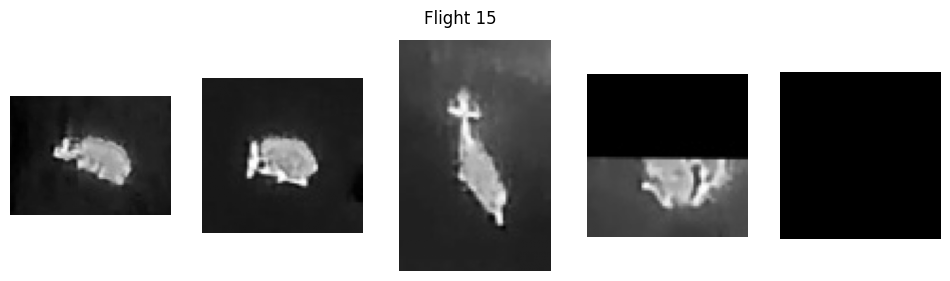

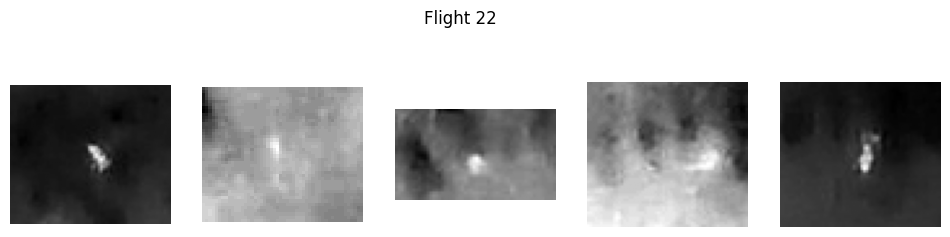

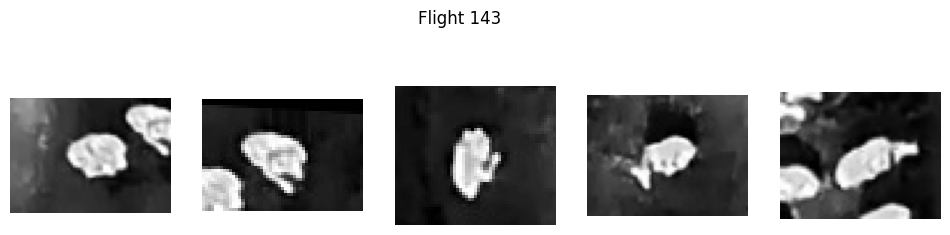

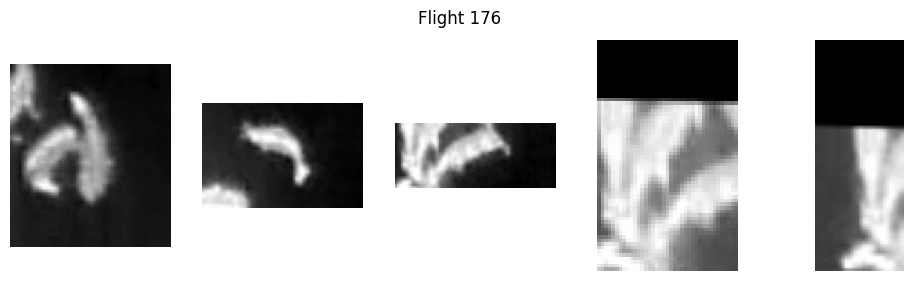

In [ ]:
# comparing different flights, same species (Red Deers)
for flight in [15, 22, 143, 176]:

    imgs = [
        img for img, f, y in zip(X_val, flight_val, y_val)
        if int(f) == flight and y == 1
    ]

    fig, axs = plt.subplots(1, 5, figsize=(12, 3))

    for ax, img in zip(axs, imgs[:5]):
        ax.imshow(img, cmap="gray")
        ax.axis("off")

    plt.suptitle(f"Flight {flight}")
    plt.show()

Comparing the different flights above, they seem vastly different. In flight 15, there are deers clearly detectable, igoring the full black image on the right. However, in flight 22 there are only light dots visible, I cannot really make out an animale shape. While flight 143 shows lying deers (what is also different to the standing ones in flight 15), in flight 176 the animals are very blurry, but the animals still visible.

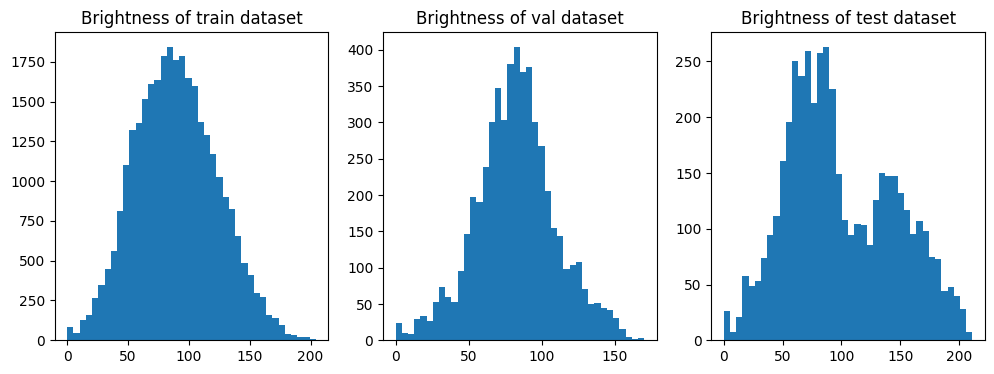

In [16]:
train_bright = [np.array(img).mean() for img in X_train]
val_bright = [np.array(img).mean() for img in X_val]
test_bright = [np.array(img).mean() for img in X_test]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(train_bright, bins=40)
ax[0].set_title(f"Brightness of train dataset")

ax[1].hist(val_bright, bins=40)
ax[1].set_title(f"Brightness of val dataset")

ax[2].hist(test_bright, bins=40)
ax[2].set_title(f"Brightness of test dataset")
plt.show()

TODO interpret the brightnesses

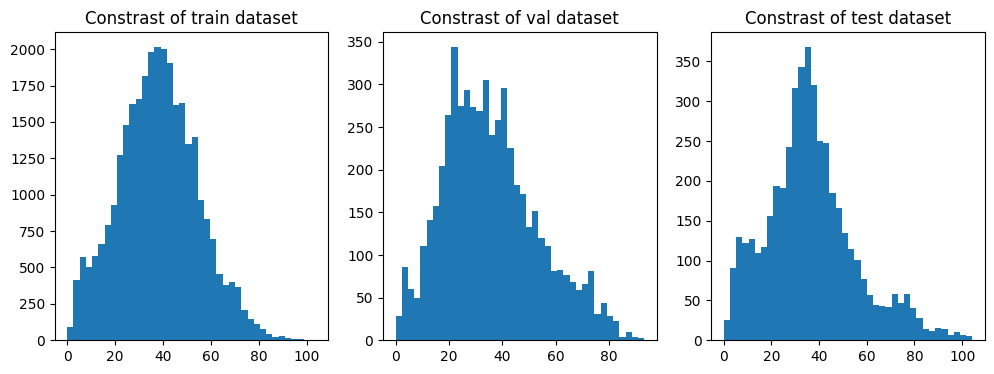

In [17]:
train_contrast = [np.array(img).std() for img in X_train]
val_contrast = [np.array(img).std() for img in X_val]
test_constrast = [np.array(img).std() for img in X_test]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(train_contrast, bins=40)
ax[0].set_title(f"Constrast of train dataset")

ax[1].hist(val_contrast, bins=40)
ax[1].set_title(f"Constrast of val dataset")

ax[2].hist(test_constrast, bins=40)
ax[2].set_title(f"Constrast of test dataset")
plt.show()

TODO interpret contrast

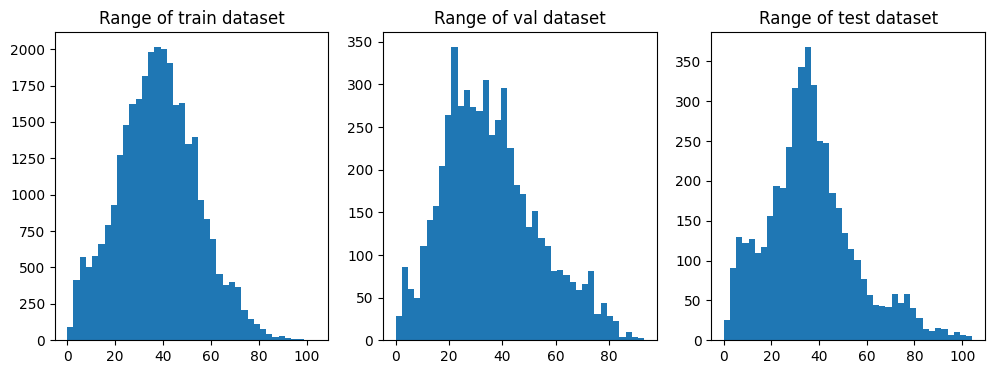

In [18]:
train_range = [np.array(img).max() - np.array(img).min() for img in X_train]
val_range = [np.array(img).max() - np.array(img).min() for img in X_val]
test_range = [np.array(img).max() - np.array(img).min() for img in X_test]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(train_contrast, bins=40)
ax[0].set_title(f"Range of train dataset")

ax[1].hist(val_contrast, bins=40)
ax[1].set_title(f"Range of val dataset")

ax[2].hist(test_constrast, bins=40)
ax[2].set_title(f"Range of test dataset")
plt.show()

TODO interpret range

In [ ]:
X = X_train + X_val + X_test
flight_ids = flight_train + flight_val + flight_test
labels = y_train + y_val + y_test

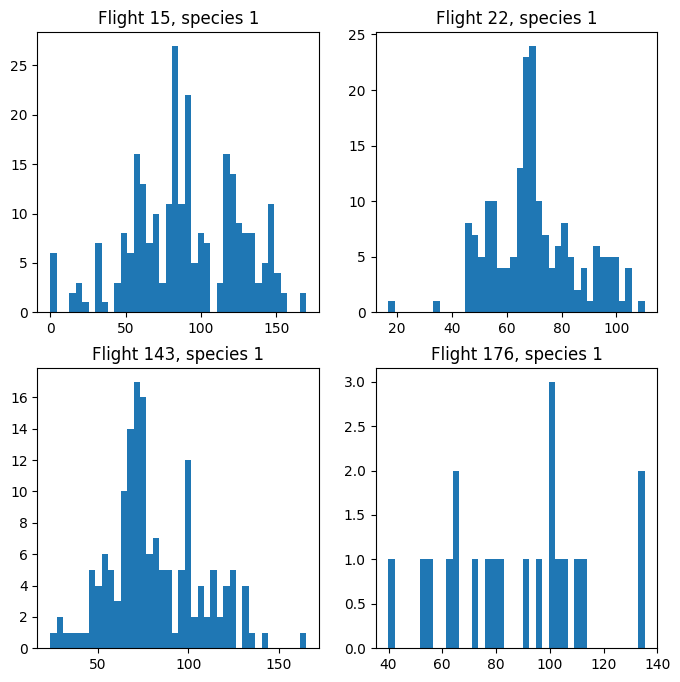

In [29]:
brightnesses1 = [np.array(img).mean()
    for img, f, y in zip(X, flight_ids, labels)
    if int(f) == 15 and y == 1]

brightnesses2 = [np.array(img).mean()
    for img, f, y in zip(X, flight_ids, labels)
    if int(f) == 22 and y == 1]

brightnesses3 = [np.array(img).mean()
    for img, f, y in zip(X, flight_ids, labels)
    if int(f) == 143 and y == 1]

brightnesses4 = [np.array(img).mean()
    for img, f, y in zip(X, flight_ids, labels)
    if int(f) == 176 and y == 1]

fig, ax = plt.subplots(2, 2, figsize=(8, 8))
ax[0, 0].hist(brightnesses1, bins=40)
ax[0, 0].set_title("Flight 15, species 1")
ax[0, 1].hist(brightnesses2, bins=40)
ax[0, 1].set_title("Flight 22, species 1")
ax[1, 0].hist(brightnesses3, bins=40)
ax[1, 0].set_title("Flight 143, species 1")
ax[1, 1].hist(brightnesses4, bins=40)
ax[1, 1].set_title("Flight 176, species 1")
plt.show()

## Investigating Black Images (Noise)

I found out that some images are completely black (std==0 and/or range==0)

In [ ]:
bad = 0 # bad images are image crops that are completely black

for img in X:
    arr = np.asarray(img)
    if arr.std() == 0:
        bad += 1

print(bad)
print(bad / len(X)) # luckily only 59 out of the whole dataset -> we can neglect that fact, esp. as it only affects very few img per flight and species

59
0.0014361171287393813


The good thing is that only 59 out of the whole dataset are completely black (= noise). As a result, I can neglect that fact.

In [ ]:
counter = Counter()
for img, fid, y in zip(X, flight_ids, labels):

    arr = np.asarray(img)

    if arr.std() == 0:
        counter[(fid, y)] += 1

print(counter)

Counter({('17', 2): 13, ('132', 1): 9, ('138', 3): 6, ('140', 3): 6, ('46', 3): 4, ('137', 3): 4, ('15', 1): 4, ('14', 1): 4, ('163', 1): 2, ('96', 3): 1, ('78', 3): 1, ('141', 3): 1, ('136', 3): 1, ('56', 0): 1, ('57', 0): 1, ('55', 1): 1})


There is not one flight containing all of the completely black images, therefore I will just ignore the fact that they are part of the dataset.

In [ ]:
for c in np.unique(y_train):
    print(c, X_train[y_train==c].mean(), X_val[y_val==c].mean(), X_test[y_test==c].mean())

## Comparing Images over all Flights

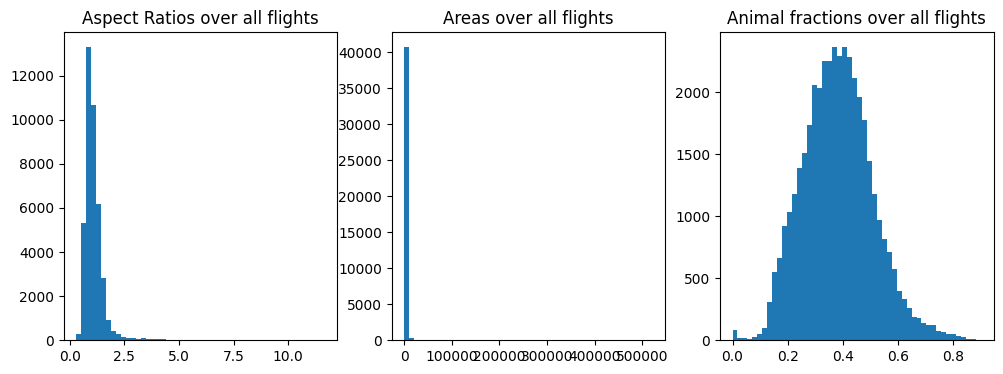

In [ ]:
areas = []
aspects = []
fractions = []
for img in X: 
    h, w = img.size

    area = h * w   
    areas.append(area)
    aspect = w / h
    aspects.append(aspect)
    
    img = np.array(img) 
    mask = img > img.mean()
    animal_fraction = mask.mean()
    fractions.append(animal_fraction)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].set_title("Aspect Ratios over all flights")
ax[0].hist(aspects, bins=50)

ax[1].hist(areas, bins=50)
ax[1].set_title("Areas over all flights")

ax[2].hist(fractions, bins=50)
ax[2].set_title("Animal fractions over all flights")
plt.show()

TODO interpret

In [ ]:
shapes = Counter([img.size for img in X])

for shape, count in shapes.most_common(20):
    print(shape, count)

(66, 94) 415
(68, 50) 280
(67, 94) 269
(69, 58) 265
(62, 70) 171
(70, 59) 170
(58, 51) 166
(68, 70) 152
(56, 50) 140
(46, 44) 135
(62, 62) 134
(54, 64) 126
(26, 24) 123
(62, 56) 123
(24, 20) 120
(62, 46) 120
(63, 68) 118
(68, 63) 114
(48, 42) 111
(26, 27) 110


In [48]:
areas = [img.size[0]*img.size[1] for img in X]

print(np.percentile(areas, [1,5,10,25,50,75,90,95,99]))

[ 624. 1443. 1890. 2680. 3685. 4900. 6298. 7200. 9800.]


TODO interpet

## Investigating RGB Images

Because classification only on the thermal images did not lead to great results, I decided to also pass the RGB images as input. Since the labels for the thermal and RGB dataset differ, I adjusted the RGB labels with the help of this GitHub Repository https://github.com/HugoMarkoff/BAMBI_BBox_Corrections.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

train = np.load("../train.npz")
X_train = train["X"]
y_train = train["y"]

val = np.load("../val.npz")
X_val = val["X"]
y_val = val["y"]

test = np.load("../test.npz")
X_test = test["X"]
y_test = test["y"]

X_train_rgb = X_train[:, :, :, 1:]
X_val_rgb = X_val[:, :, :, 1:]
X_test_rgb = X_test[:, :, :, 1:]

X_train_thermal = X_train[:, :, :, 0:1]
X_val_thermal = X_val[:, :, :, 0:1]
X_test_thermal = X_test[:, :, :, 0:1]

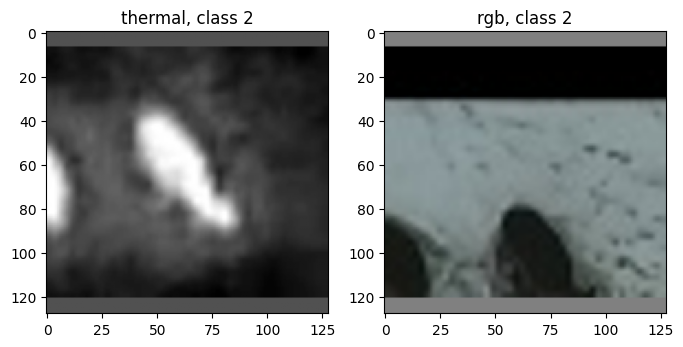

In [9]:
i = np.random.randint(len(X_train))

thermal = X_train[i,:,:,0]
rgb = X_train[i,:,:,1:]

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].imshow(thermal, cmap="gray")
ax[0].set_title(f"thermal, class {y_train[i]}")

ax[1].imshow(rgb)
ax[1].set_title(f"rgb, class {y_train[i]}")

plt.show() # this shows the problem with the rgb images -> the animals are completely hiddens

Still after adjusting the RGB labels using the suggested GitHub Repository, some RGB image crops cut off the animal and don't center it!

In [ ]:
for c in np.unique(y_train):
    print(c, X_train_rgb[y_train==c].mean(), X_val_rgb[y_val==c].mean(), X_test_rgb[y_test==c].mean())

0 0.4230355 0.52164626 0.38185683
1 0.42460495 0.37091747 0.41686347
2 0.47207353 0.3350285 0.40628076
3 0.41451883 0.40878865 0.40732086
4 0.36019364 0.41298887 0.46630767


The mean pixel values across all classes and splits are very similar.

In [ ]:
flight_train = np.array(flight_train, dtype=np.int32)
flight_val = np.array(flight_val, dtype=np.int32)
flight_test = np.array(flight_test, dtype=np.int32)

In [ ]:
for flight in np.unique(flight_train):
    imgs = X_train_thermal[flight_train == flight]

    print(flight, imgs.mean(), imgs.std(), imgs.min(), imgs.max())

0 -0.68520653 0.4892958 -1.9445431 3.16849
1 -0.3914021 0.8602536 -1.9445431 3.16849
2 -0.28398633 0.8002617 -1.9445431 3.16849
3 -0.020573877 0.74340606 -1.9445431 3.16849
17 -0.021968508 1.1662053 -1.9445431 3.16849
18 0.80797404 0.87870884 -1.9445431 3.16849
20 0.17846416 0.82594687 -1.9445431 3.0481832
21 0.30605078 1.0368464 -1.9445431 2.9679787
26 0.044653695 1.3069515 -1.9445431 3.16849
27 0.25928286 1.2250434 -1.9445431 3.16849
28 -0.2754913 0.95732576 -1.9445431 3.16849
29 -0.469779 1.207574 -1.9445431 3.16849
30 -0.5383857 1.1334378 -1.9445431 3.16849
31 -0.4223166 0.9600891 -1.9445431 3.16849
32 -0.11828466 0.8736884 -1.9445431 3.16849
33 -0.32171118 0.99220407 -1.9445431 3.16849
34 -0.42243487 1.0740615 -1.9445431 3.16849
35 -0.51146024 1.0682982 -1.9445431 3.16849
36 -0.29804307 1.0734226 -1.9445431 3.16849
37 -0.41026902 0.85352504 -1.9445431 3.16849
40 0.19497892 0.8999076 -1.9445431 3.16849
41 -0.41488874 0.8984222 -1.9445431 3.16849
42 -0.2638638 1.0509349 -1.9445431 3

In [ ]:
for flight in np.unique(flight_val):
    imgs = X_val_thermal[flight_val == flight]

    print(flight, imgs.mean(), imgs.std(), imgs.min(), imgs.max())

6 -0.06826571 0.9274386 -1.9445431 3.16849
10 -0.11704056 0.7819097 -1.9445431 3.16849
13 -0.31673503 1.0552466 -1.9445431 3.16849
14 -0.14724703 1.058397 -1.9445431 3.16849
15 0.055683795 1.1946781 -1.9445431 3.16849
22 -0.37542883 0.57924587 -1.9445431 3.16849
56 -0.23664415 0.5754866 -1.9445431 3.1283877
57 -0.36317268 0.70211995 -1.9445431 3.16849
59 -0.06017558 0.58723027 -1.9445431 0.8425612
64 0.049984276 0.623094 -1.9445431 1.0029701
66 -0.43800807 0.9164901 -1.9445431 3.16849
67 0.5944149 0.6324678 -0.88183427 3.16849
87 -0.23763886 0.44112587 -1.6838787 1.8050145
89 0.11676612 0.7959486 -1.9445431 2.5870078
142 0.34881243 0.83695257 -1.9445431 3.16849
143 -0.35347807 1.3397212 -1.9445431 3.16849
150 -0.1300006 0.6563881 -1.9445431 2.5068033
175 0.11186124 0.6112521 -1.9445431 2.08573
176 0.06806842 1.1497536 -1.9445431 3.16849
177 -0.41756266 1.1584207 -1.9445431 3.16849
178 0.032616068 1.0489798 -1.9445431 3.16849
221 -0.41919068 0.7055859 -1.9445431 3.16849
222 -0.24881683 

In [ ]:
for flight in np.unique(flight_test):
    imgs = X_test_thermal[flight_test == flight]

    print(flight, imgs.mean(), imgs.std(), imgs.min(), imgs.max())

50 -0.4145402 0.75285673 -1.9445431 0.62199897
55 -0.09290065 1.0996451 -1.9445431 3.16849
135 -0.16768175 0.8537556 -1.9445431 3.16849
140 0.33494917 1.0382165 -1.9445431 3.16849
152 -0.062380206 0.500949 -1.9445431 3.16849
159 -0.036433876 1.0697068 -1.9445431 3.16849
160 -0.483162 0.930364 -1.9445431 3.16849
161 0.19558941 1.1412306 -1.9445431 3.16849
162 -0.35176077 1.0544974 -1.9445431 3.16849
163 0.1130251 1.2433699 -1.9445431 3.16849
250 0.14119038 1.4458362 -1.9445431 3.16849
252 -0.26783413 1.0805372 -1.9445431 3.16849
260 -0.7453107 0.9866859 -1.9445431 3.16849
261 -0.5449167 0.93039477 -1.9445431 3.16849
262 -0.00883594 1.1902505 -1.9445431 3.16849
263 -0.38520342 1.2536296 -1.9445431 3.16849
264 -0.2040053 0.993562 -1.9445431 3.16849
265 -1.0862297 0.93027884 -1.9445431 3.16849
266 -0.2551932 0.98178905 -1.924492 3.16849
267 1.2910595 0.37374362 0.62199897 3.16849
276 0.7739134 1.0786955 -1.9445431 3.16849
277 1.050654 0.98169553 -1.9445431 3.16849
278 -0.07679803 1.077049 

10299


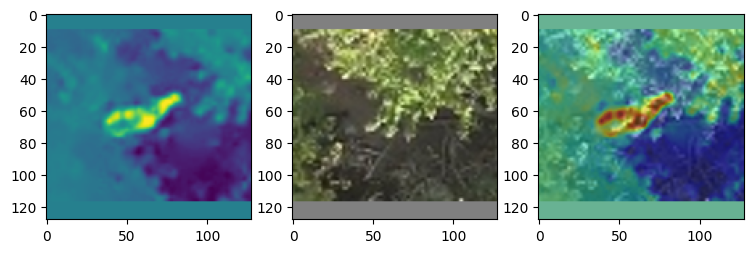

20147


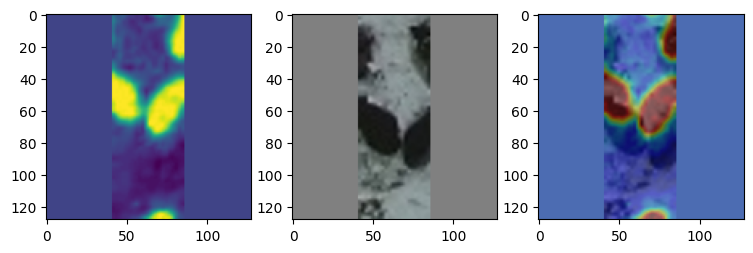

11182


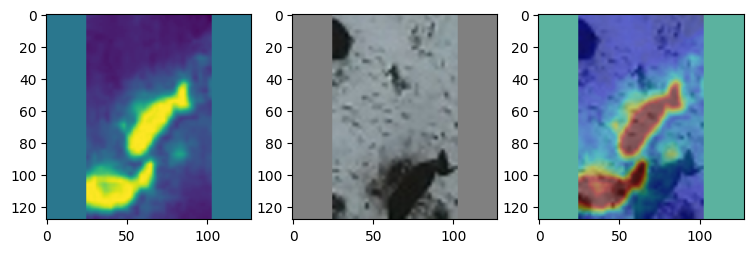

3351


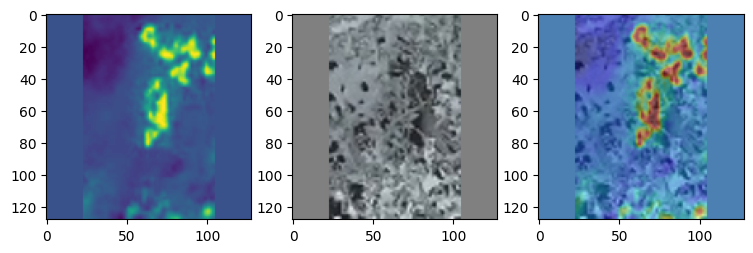

4132


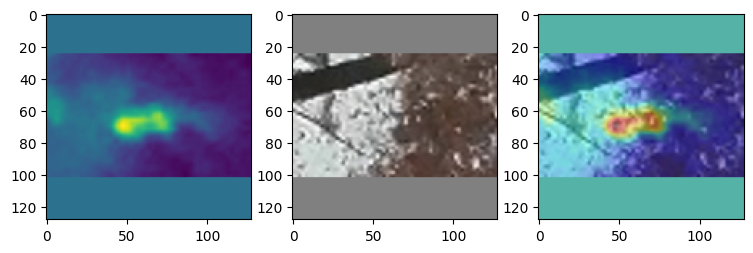

16522


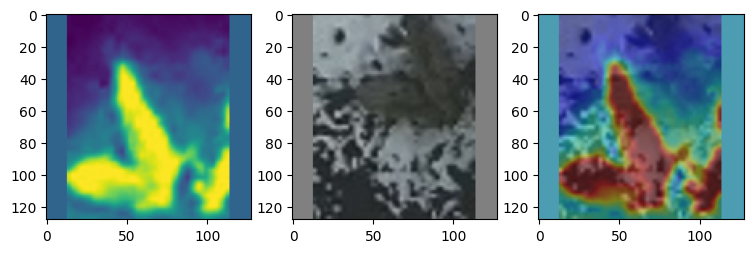

7323


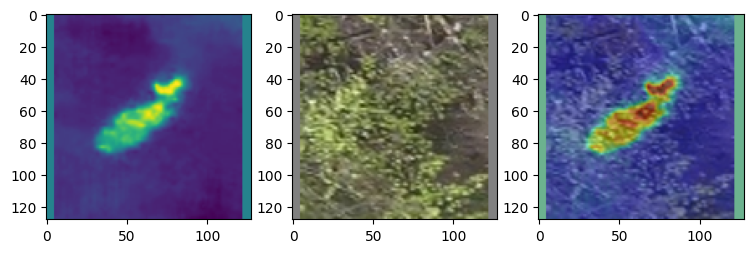

30804


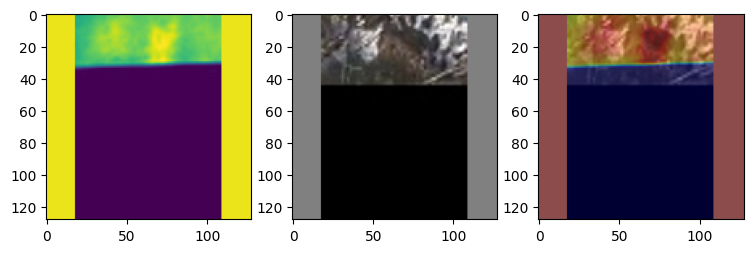

19679


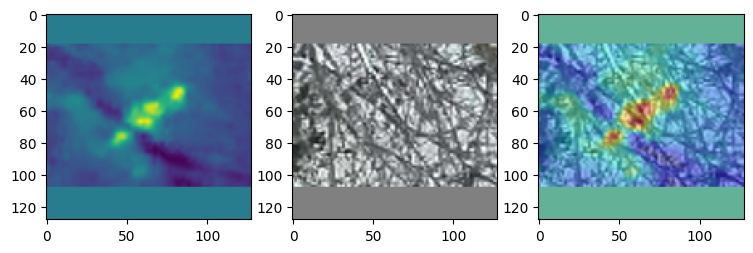

1989


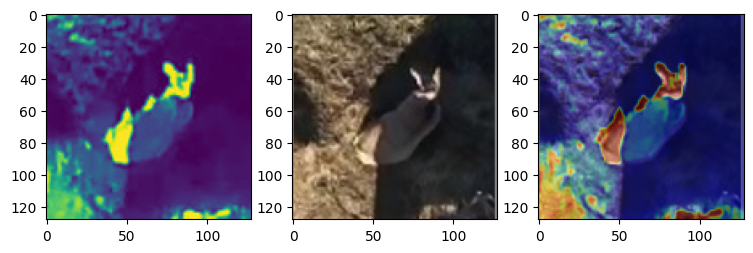

In [12]:
for i in np.random.choice(len(X_train),10):
    print(i)
    plt.figure(figsize=(9,3))

    plt.subplot(131)
    plt.imshow(X_train_thermal[i])

    plt.subplot(132)
    plt.imshow(X_train_rgb[i])

    plt.subplot(133)
    plt.imshow(X_train_rgb[i])
    plt.imshow(X_train_thermal[i], alpha=0.4, cmap="jet")

    plt.show()

The output above shows that in the minority of cases the animal is in the same place in the thermal and the RGB image. Sometimes, I cannot verify either case because the animal is hidden behind trees. However, most of the times the animal in the RGB image is cut off or not in the center. 

This is the great problem I am facing. 

## Masked RGB Images

Since I included more context margin when cropping the images, I thought these additional surroundings might be distracting for the RGB images, so I was thinking of masking the RGB images. Everything in the RGB image is black except for the animal figure in the corresponding thermal image.

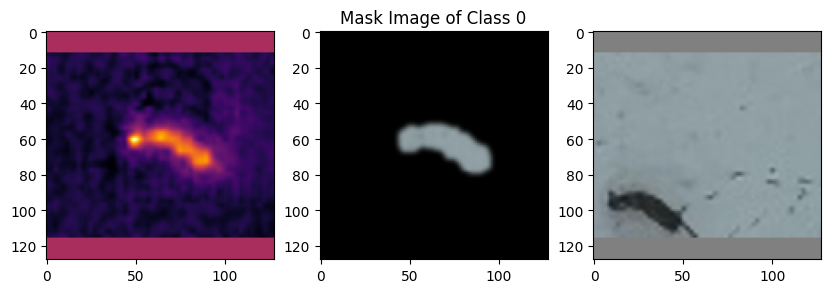

In [86]:
from species_classification import mask_rgb
masked_rgbs = mask_rgb(X_val)

idx = 100
fig, ax = plt.subplots(1, 3, figsize=(10, 6))
ax[0].imshow(X_val[idx,:,:,0], cmap='inferno')

ax[1].imshow(masked_rgbs[idx, :, :, 1:], cmap='inferno')

ax[2].imshow(X_val[idx,:,:,1:])
ax[1].set_title(f"Mask Image of Class {y_val[idx]}")
plt.show()

If I then apply a mask that makes everything black in the RGB image but the pixels, where the animal is in the thermal image, this is not useful at all for training as in the worst case, the mask does not include the animal. 